# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Muhamad Aditya Umar Faiz
- Email: umaygans03@gmail.com
- Id Dicoding: 

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)


sns.set_theme(style="whitegrid")

### Menyiapkan data yang akan diguankan

## Data Understanding

In [3]:
df = pd.read_csv("data/data.csv", sep=None, engine="python", encoding="utf-8-sig")
df.sample(10)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
2009,1,1,6,9773,1,1,133.1,1,1,1,90,90,129.6,0,0,0,1,0,0,22,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,7.6,2.6,0.32,Dropout
3475,1,17,1,9085,1,1,131.0,1,38,38,191,174,125.4,1,0,0,1,0,0,20,0,0,6,13,6,15.692308,0,0,6,13,5,14.428571,0,15.5,2.8,-4.06,Graduate
1504,1,39,1,9500,1,40,130.0,1,37,37,9,7,130.0,0,0,0,1,0,0,27,0,3,8,12,7,12.457143,0,3,8,12,7,12.457143,0,12.7,3.7,-1.70,Enrolled
689,4,39,2,9147,1,19,133.1,1,37,37,9,7,116.4,0,0,1,0,1,0,70,0,0,5,5,0,0.000000,0,0,5,9,0,0.000000,0,10.8,1.4,1.74,Dropout
4001,1,42,1,9119,1,1,140.0,1,3,3,3,2,133.6,1,0,0,1,1,0,22,0,0,5,0,0,0.000000,0,0,5,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1567,1,1,2,9147,1,1,108.0,1,1,19,4,4,105.9,1,0,0,1,1,0,21,0,0,5,9,4,10.750000,0,0,5,6,5,11.400000,0,11.1,0.6,2.02,Graduate
2732,1,1,1,9500,1,1,131.0,1,19,19,4,4,122.0,1,0,0,1,0,0,20,0,0,8,8,7,14.014286,0,0,8,8,7,14.014286,0,12.7,3.7,-1.70,Enrolled
3874,1,39,1,9130,1,1,133.1,1,1,1,90,1,120.0,1,0,1,0,1,0,41,0,0,5,5,0,0.000000,1,0,5,5,0,0.000000,5,12.7,3.7,-1.70,Dropout
2498,1,39,1,171,1,19,133.1,101,1,19,2,7,110.0,0,0,0,1,1,1,25,1,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,15.5,2.8,-4.06,Dropout
1828,1,7,1,9500,1,3,120.0,1,37,37,4,5,120.0,0,0,1,0,0,0,28,0,0,7,7,0,0.000000,7,0,7,7,0,0.000000,7,13.9,-0.3,0.79,Dropout


In [3]:
print("DATASET SHAPE")
print("="*50)
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n")
print("DATASET INFO")
print("="*50)

df.info()

DATASET SHAPE
Rows   : 4424
Columns: 37


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_

In [4]:
def data_quality_report(df):
    print("="*70)
    print("BASIC STRUCTURE")
    print("="*70)
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")
    print()
    
    print("="*70)
    print("MISSING VALUES")
    print("="*70)
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        "Missing Count": missing,
        "Missing (%)": missing_pct
    })
    print(missing_df[missing_df["Missing Count"] > 0])
    print()

    print("="*70)
    print("DUPLICATE ROWS")
    print("="*70)
    print(f"Total duplicates: {df.duplicated().sum()}")
    print()

    print("="*70)
    print("CARDINALITY CHECK")
    print("="*70)
    cardinality = df.nunique().sort_values()
    print(cardinality)
    print()

    print("="*70)
    print("NUMERICAL SUMMARY")
    print("="*70)
    display(df.describe(include=[np.number]).T)    
    
    print("="*70)
    print("CATEGORICAL SUMMARY")
    print("="*70)
    display(df.describe(include=["object"]).T)

In [5]:
data_quality_report(df)

BASIC STRUCTURE
Rows    : 4424
Columns : 37

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []

DUPLICATE ROWS
Total duplicates: 0

CARDINALITY CHECK
Scholarship_holder                                2
International                                     2
Gender                                            2
Tuition_fees_up_to_date                           2
Daytime_evening_attendance                        2
Debtor                                            2
Educational_special_needs                         2
Displaced                                         2
Status                                            3
Marital_status                                    6
Application_order                                 8
Inflation_rate                                    9
Unemployment_rate                                10
Curricular_units_2nd_sem_without_evaluations     10
GDP                                              10
Curricular_units_1st_sem_without_evaluati

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


CATEGORICAL SUMMARY


,count,unique,top,freq
Status,4424,3,Graduate,2209


In [6]:
display(df["Status"].value_counts())
display((df["Status"].value_counts(normalize=True) * 100).round(2))

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

In [7]:
range_cols = [
    "Previous_qualification_grade",   # 0-200
    "Admission_grade",                # 0-200
    "Curricular_units_1st_sem_grade", # 0-20
    "Curricular_units_2nd_sem_grade", # 0-20
    "Age_at_enrollment"
]

for col in range_cols:
    print(f"{col:40} min={df[col].min()}  max={df[col].max()}")

Previous_qualification_grade             min=95.0  max=190.0
Admission_grade                          min=95.0  max=190.0
Curricular_units_1st_sem_grade           min=0.0  max=18.875
Curricular_units_2nd_sem_grade           min=0.0  max=18.571428571428573
Age_at_enrollment                        min=17  max=70


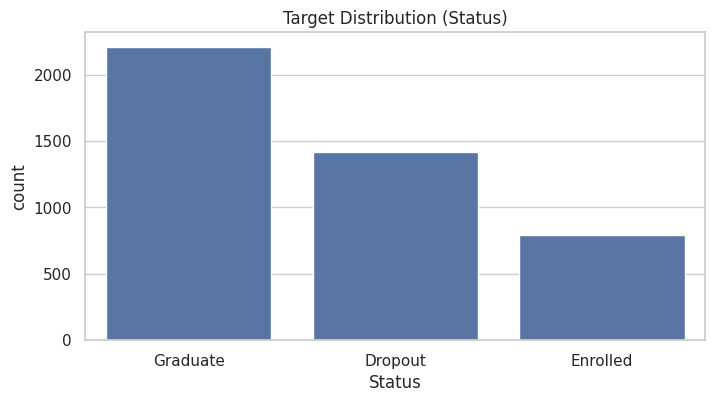

In [8]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Status", order=df["Status"].value_counts().index)
plt.title("Target Distribution (Status)")
plt.show()

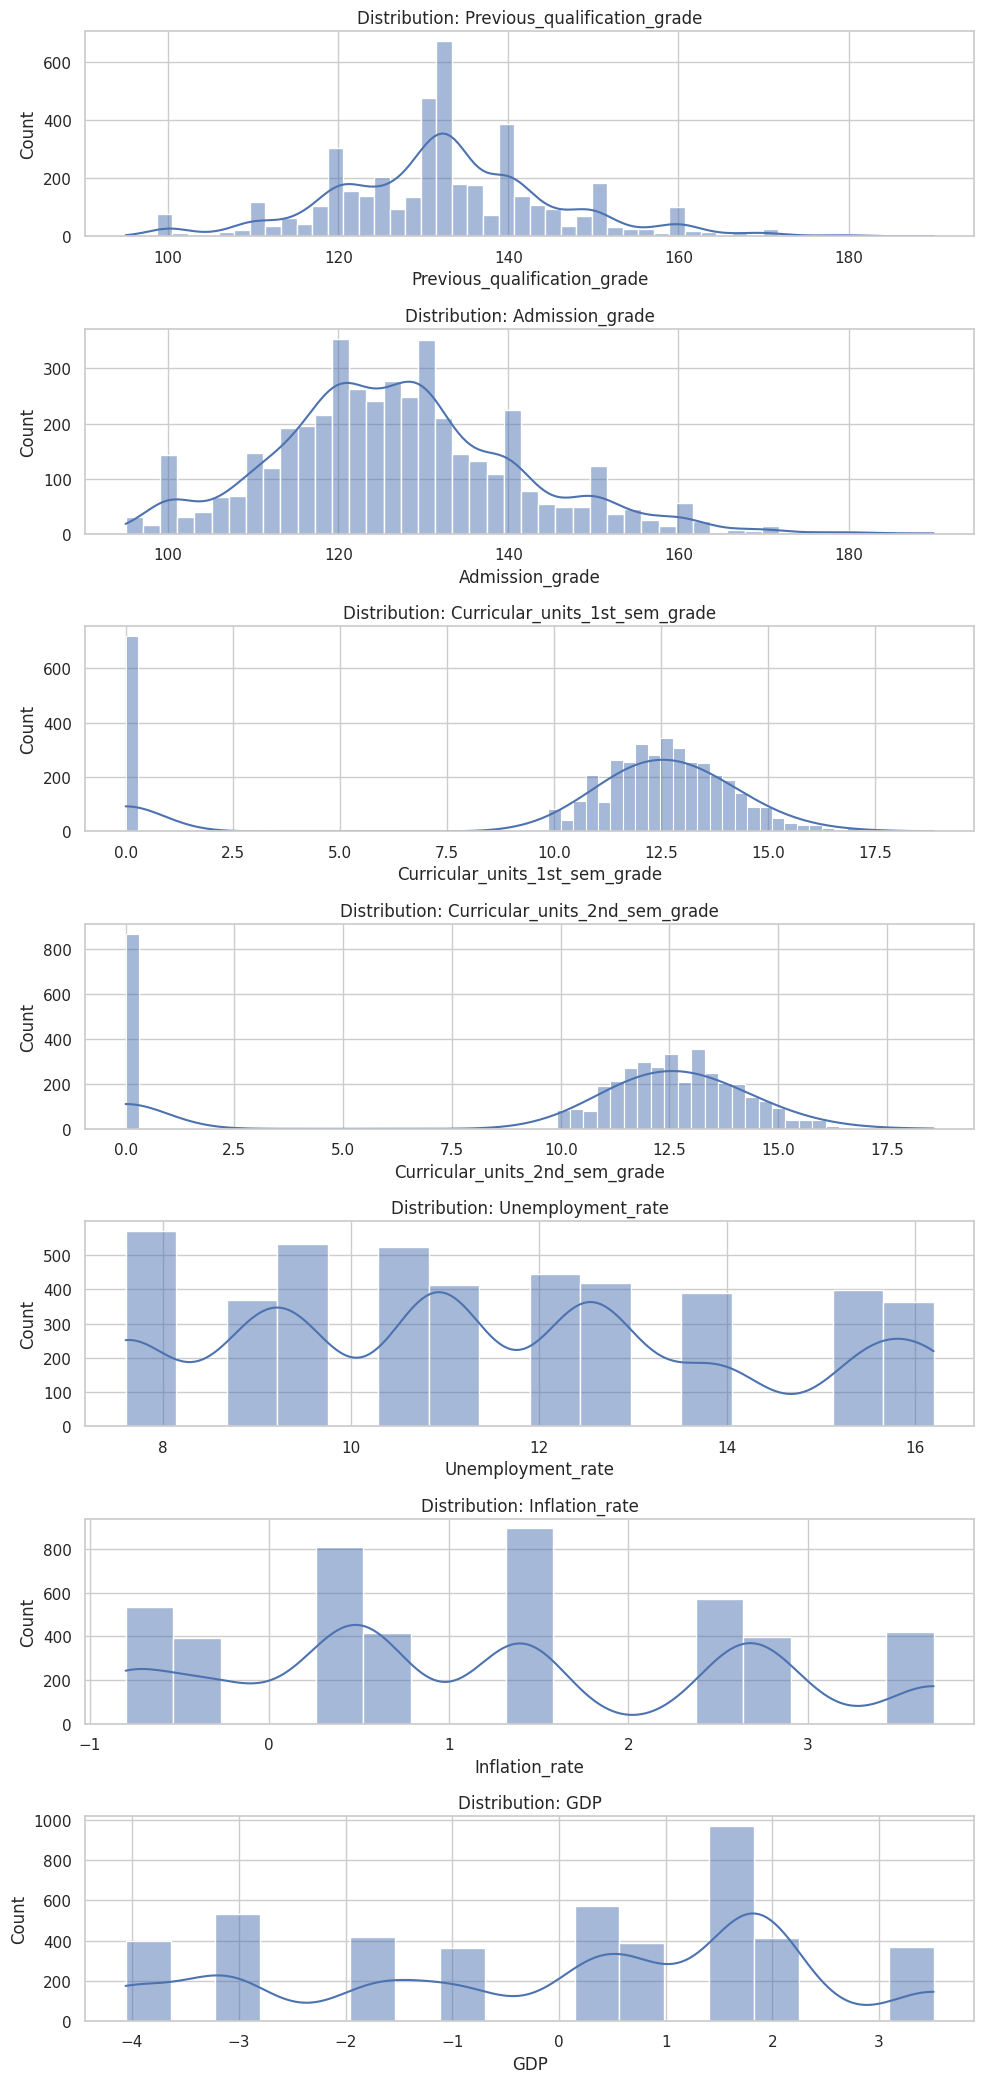

In [9]:
numeric_cols = df.select_dtypes(include=["float64"]).columns.tolist()

fig, ax = plt.subplots(len(numeric_cols), 1, figsize=(10, 3*len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax[i])
    ax[i].set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

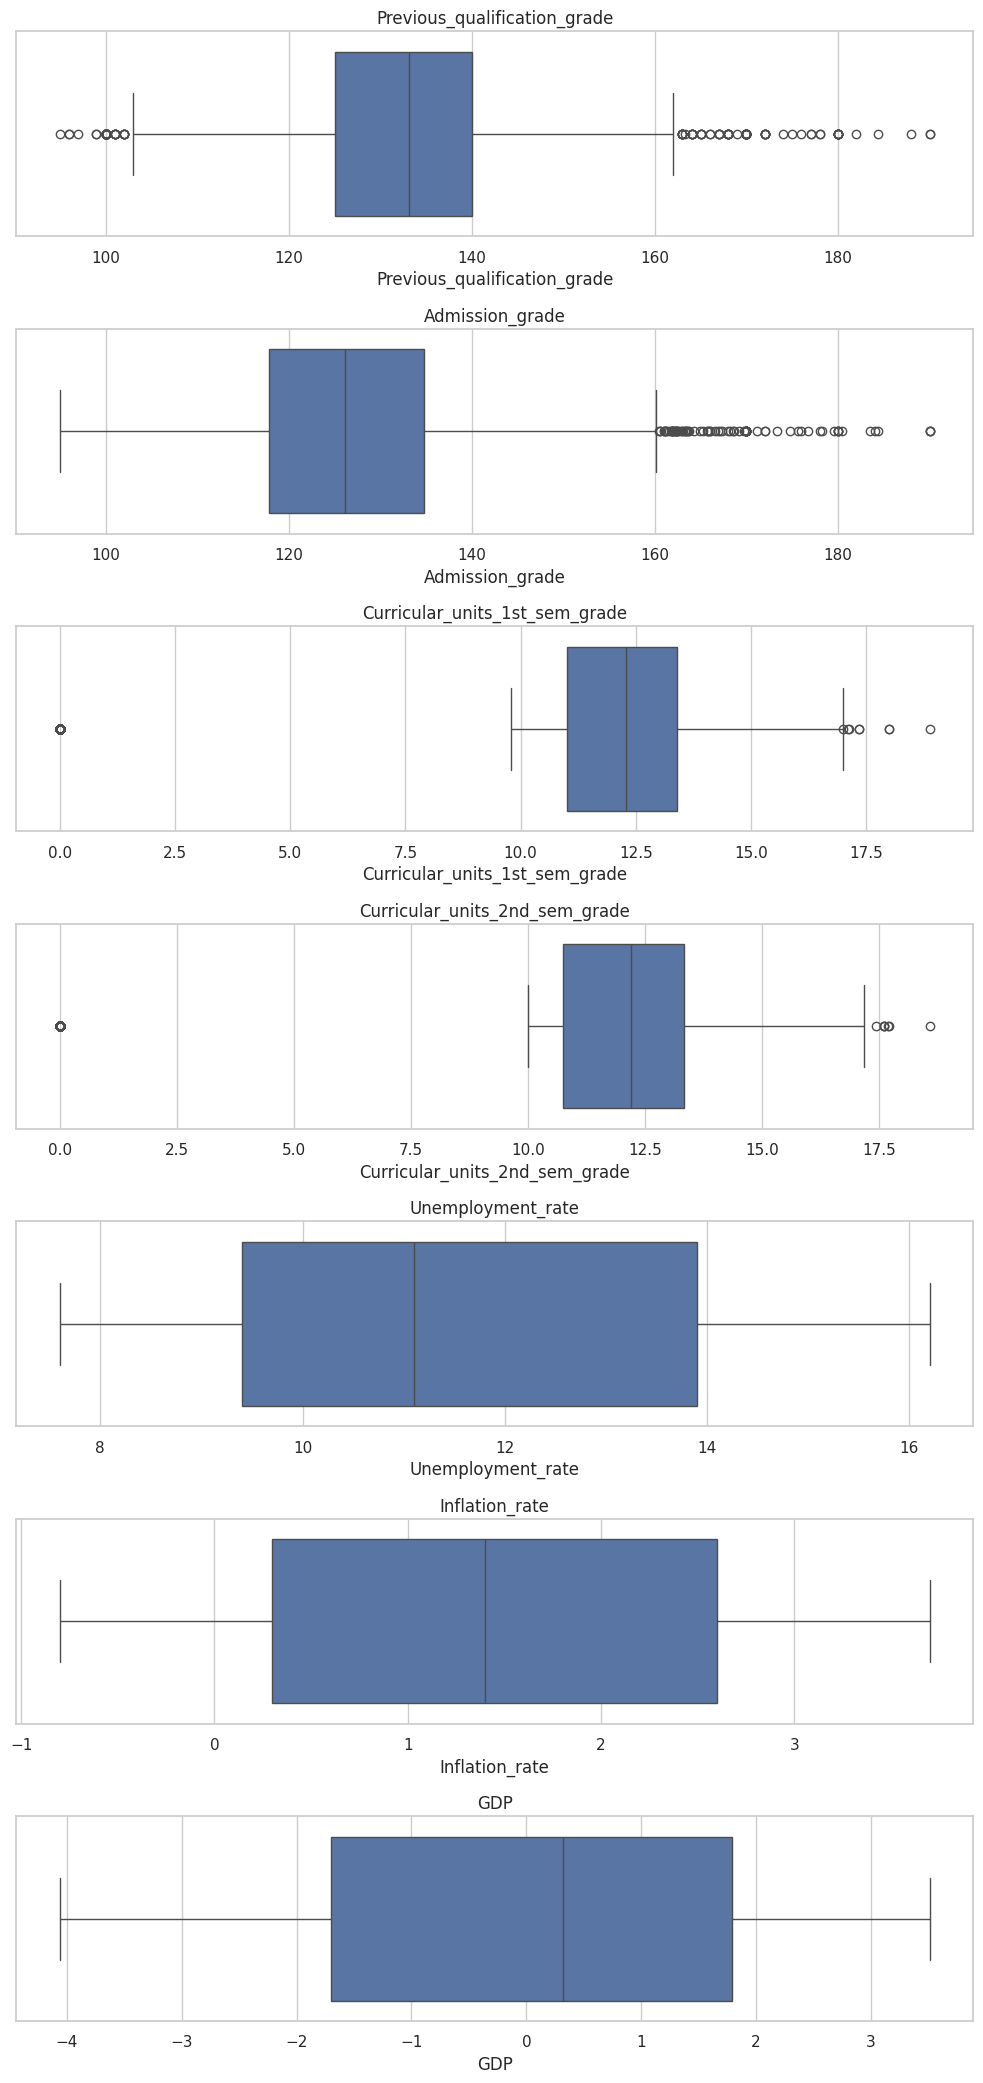

In [10]:
fig, ax = plt.subplots(len(numeric_cols), 1, figsize=(10, 3*len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=ax[i])
    ax[i].set_title(f"{col}")
plt.tight_layout()
plt.show()

In [ ]:
int_cols = df.select_dtypes(include=["int64"]).columns.tolist()

categorical_int_cols = [c for c in int_cols if df[c].nunique() <= 20]

len(categorical_int_cols), categorical_int_cols[:10]

(17,
 ['Marital_status',
  'Application_mode',
  'Application_order',
  'Course',
  'Daytime_evening_attendance',
  'Previous_qualification',
  'Displaced',
  'Educational_special_needs',
  'Debtor',
  'Tuition_fees_up_to_date'])

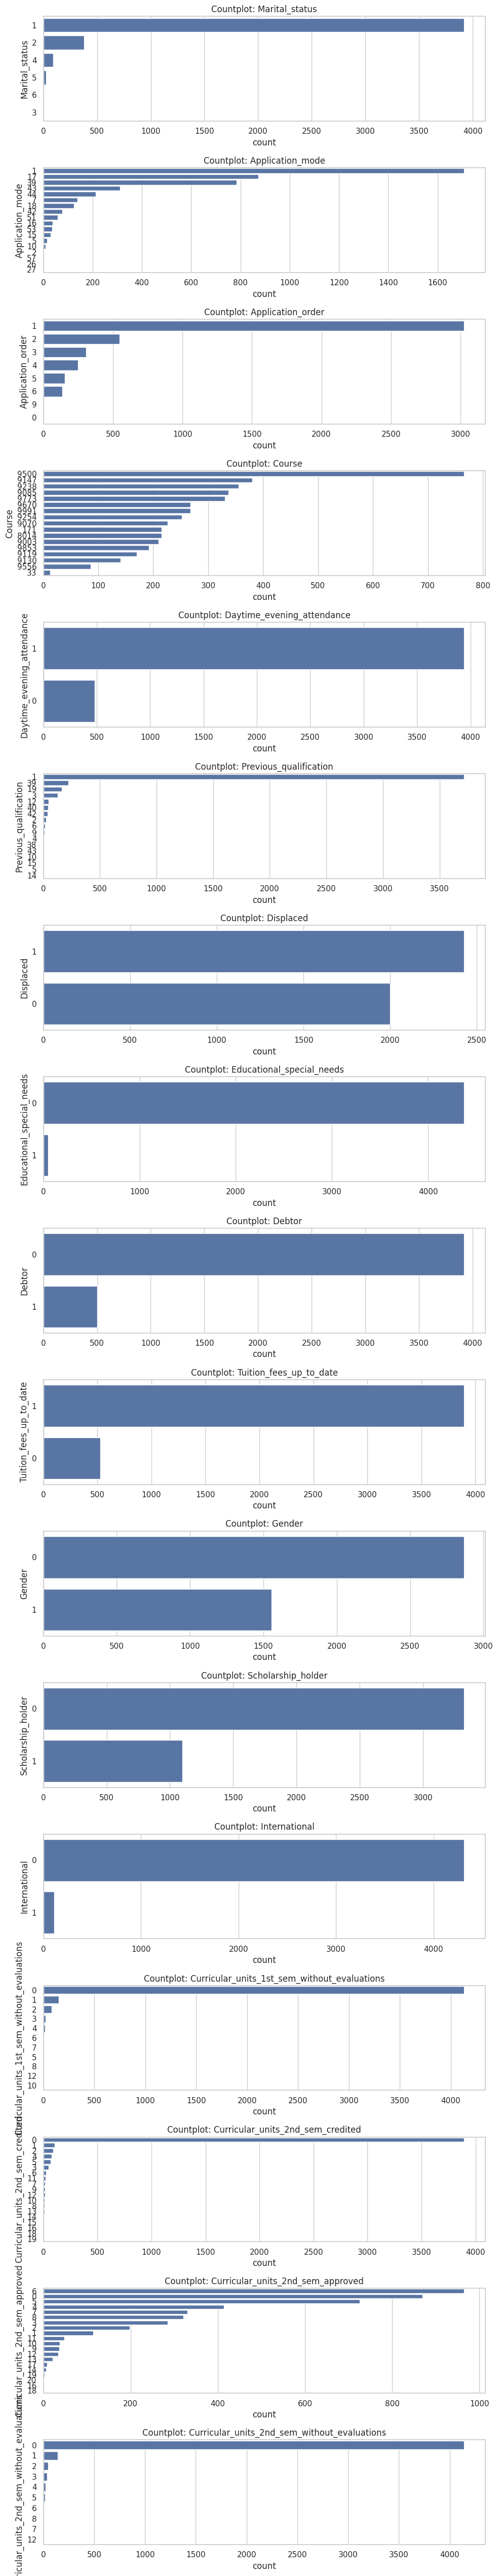

In [12]:
fig, ax = plt.subplots(len(categorical_int_cols), 1, figsize=(10, 3*len(categorical_int_cols)))

for i, feature in enumerate(categorical_int_cols):
    sns.countplot(data=df, y=feature, order=df[feature].value_counts().index, ax=ax[i])
    ax[i].set_title(f"Countplot: {feature}")

plt.tight_layout()
plt.show()

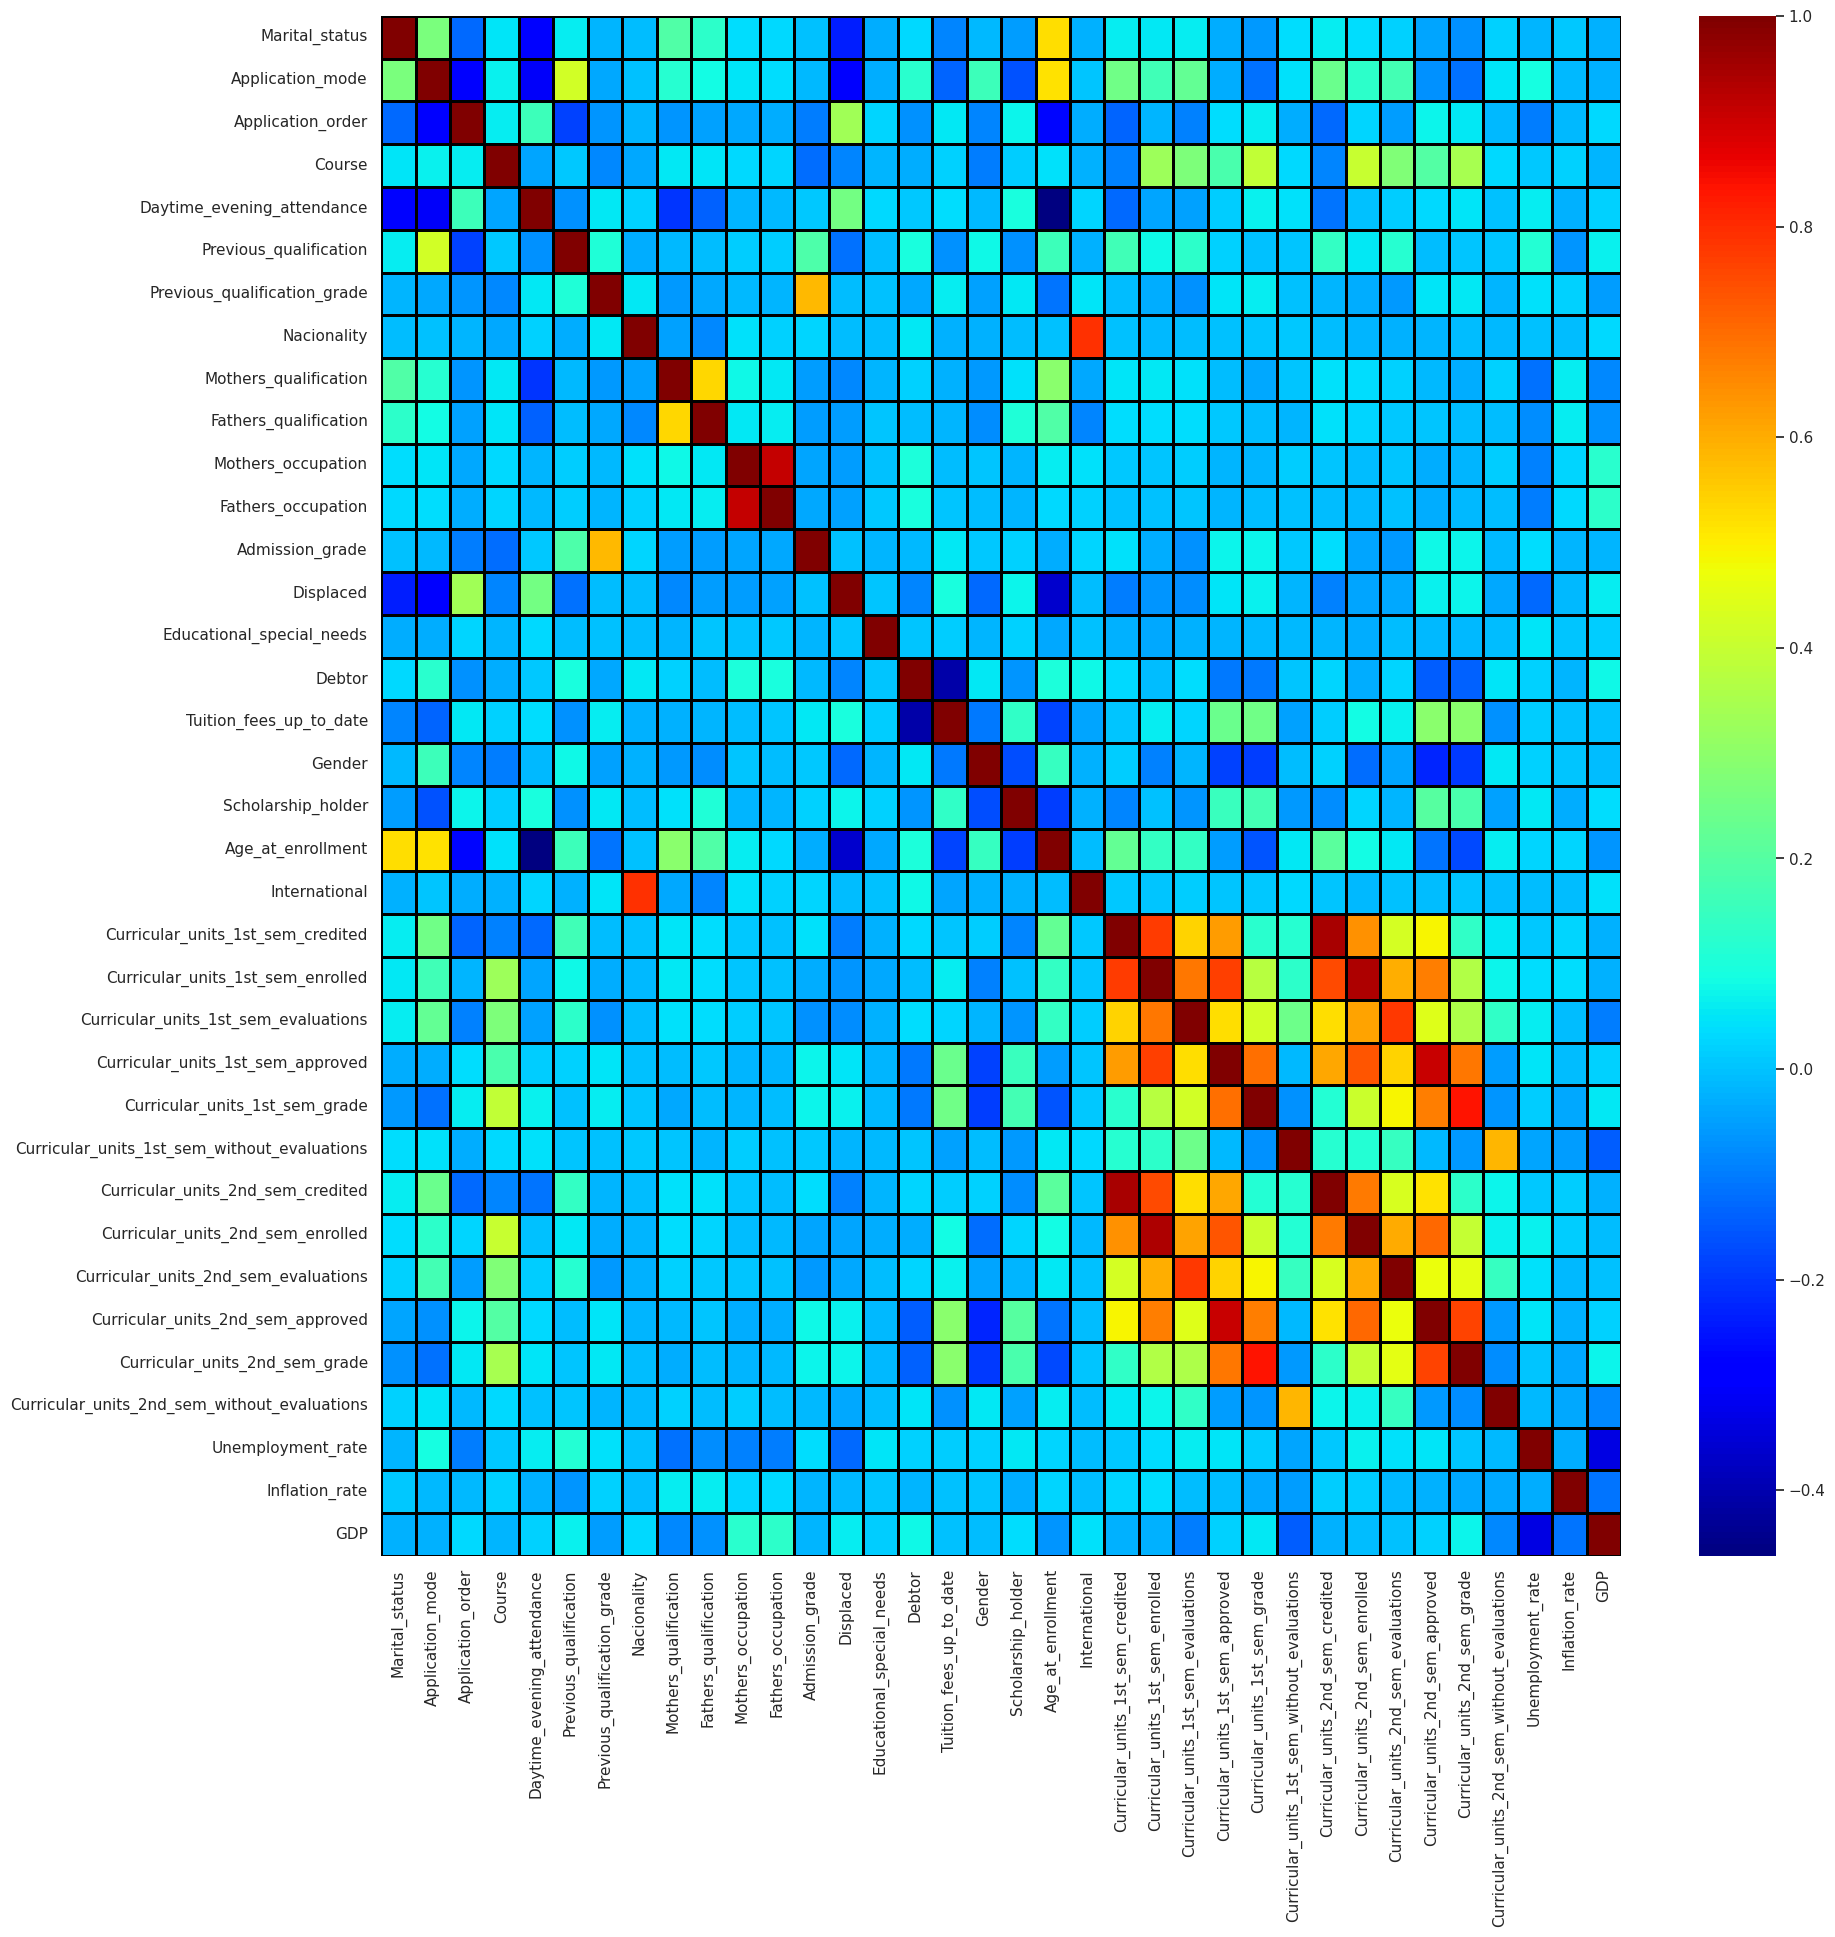

In [13]:
plt.figure(figsize=(20,20))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    cmap='jet',
    linecolor='black',
    linewidths=1
)

plt.show()

### Data Understanding Summary

1. Struktur Data
- 4.424 baris, 37 kolom  
- Tanpa missing value dan duplikasi  
→ Dataset bersih dan siap digunakan.
2. Distribusi Target
- Graduate: 49.9%
- Dropout: 32.1%
- Enrolled: 17.9%  
→ Dropout cukup signifikan untuk diprediksi.
3. Korelasi & Struktur
- Fitur akademik semester 1 & 2 sangat berkorelasi (>0.8)
- Occupation orang tua (0.91)
- Nacionality & International (0.79)  
→ Ada multicollinearity pada beberapa fitur.

4. Faktor Protektif
- Nilai & jumlah mata kuliah lulus
- Tuition up to date
- Scholarship  
→ Performa akademik dan finansial menurunkan risiko dropout.

5. Faktor Risiko
- Age at enrollment
- Debtor
- Gender
- Application mode  
→ Usia dan kondisi finansial meningkatkan risiko.

6. Insight Kunci
- Debtor: 62% dropout
- Tidak bayar tuition: 86.6% dropout
- Tanpa scholarship: 38.7% dropout  
→ Faktor finansial paling dominan.

## Data Preparation / Preprocessing

### konfigurasi untuk memasukan data  untuk ditampilkan ke dashboard

In [ ]:
df_dashboard = df.copy()

df_dashboard["is_dropout"] = (df_dashboard["Status"] == "Dropout").astype(int)
df_dashboard["is_graduate"] = (df_dashboard["Status"] == "Graduate").astype(int)
df_dashboard["is_enrolled"] = (df_dashboard["Status"] == "Enrolled").astype(int)

df_dashboard["age_group"] = pd.cut(
    df_dashboard["Age_at_enrollment"],
    bins=[16, 20, 25, 30, 100],
    labels=["17-20", "21-25", "26-30", "30+"]
)

df_dashboard["financial_risk_flag"] = (
    (df_dashboard["Debtor"] == 1) |
    (df_dashboard["Tuition_fees_up_to_date"] == 0)
).astype(int)

df_dashboard.to_csv("data/data_dashboard.csv", index=False)

In [ ]:
load_dotenv(".env") 

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"{os.getenv('POSTGRES_HOST')}:"
    f"{os.getenv('POSTGRES_PORT')}/"
    f"{os.getenv('POSTGRES_DB')}"
)

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).fetchone())

(1,)


In [37]:
df_dashboard.to_sql(
    name="student_dashboard",
    con=engine,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=1000
)

print("Table 'student_dashboard' successfully inserted into PostgreSQL.")

Table 'student_dashboard' successfully inserted into PostgreSQL.


## Preprocessing untuk modelling

In [4]:
df_model = df.copy()
df_model.to_csv("data/data_model.csv", index=False)


In [6]:
RANDOM_STATE = 42
DATA_PATH = "data/data_model.csv" 

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### define target

In [10]:
TARGET_COL = "status"

df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()

df["target_binary"] = (df[TARGET_COL] == "dropout").astype(int)

print(df[TARGET_COL].value_counts(dropna=False))
print(df["target_binary"].value_counts(dropna=False))

status
graduate    2209
dropout     1421
enrolled     794
Name: count, dtype: int64
target_binary
0    3003
1    1421
Name: count, dtype: int64


In [11]:
course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening attendance)"
}

if "course" in df.columns:
    df["course_name"] = df["course"].map(course_map).fillna("Unknown/Other")
    display(df[["course", "course_name"]].drop_duplicates().sort_values("course").head(30))
else:
    print("Kolom 'course' tidak ditemukan. Skip mapping.")

,course,course_name
35,33,Biofuel Production Technologies
0,171,Animation and Multimedia Design
4,8014,Social Service (evening attendance)
30,9003,Agronomy
2,9070,Communication Design
14,9085,Veterinary Nursing
36,9119,Informatics Engineering
18,9130,Equinculture
28,9147,Management
8,9238,Social Service


### leakage control

In [12]:
sem1_cols = [c for c in df.columns if c.startswith("curricular_units_1st_sem")]
sem2_cols = [c for c in df.columns if c.startswith("curricular_units_2nd_sem")]

print("SEM1 cols:", sem1_cols)
print("SEM2 cols:", sem2_cols)

drop_cols_base = [TARGET_COL, "target_binary"]

X_cols_enrollment = [c for c in df.columns if c not in drop_cols_base + sem1_cols + sem2_cols]

X_cols_sem1 = [c for c in df.columns if c not in drop_cols_base + sem2_cols]

print("Enrollment feature count:", len(X_cols_enrollment))
print("Sem1 feature count:", len(X_cols_sem1))

SEM1 cols: ['curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations']
SEM2 cols: ['curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations']
Enrollment feature count: 25
Sem1 feature count: 31


### Feature engineering
- financial risk
- age_bucket
- approval_rate_sem_1
- evaluation_ratio_sem1


In [13]:
def add_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Financial risk: debtor == 1 OR tuition_fees_up_to_date == 0
    if ("debtor" in df.columns) and ("tuition_fees_up_to_date" in df.columns):
        df["financial_risk"] = ((df["debtor"] == 1) | (df["tuition_fees_up_to_date"] == 0)).astype(int)
    else:
        df["financial_risk"] = 0

    # Age bucket
    if "age_at_enrollment" in df.columns:
        df["age_bucket"] = pd.cut(
            df["age_at_enrollment"],
            bins=[-np.inf, 19, 23, np.inf],
            labels=["<20", "20-23", ">23"]
        ).astype(str)
    else:
        df["age_bucket"] = "unknown"

    # Semester 1 ratio features (jika kolom tersedia)
    needed_sem1 = [
        "curricular_units_1st_sem_approved",
        "curricular_units_1st_sem_enrolled",
        "curricular_units_1st_sem_evaluations"
    ]
    if all(c in df.columns for c in needed_sem1):
        enrolled = df["curricular_units_1st_sem_enrolled"].replace(0, np.nan)
        df["approval_rate_sem1"] = (df["curricular_units_1st_sem_approved"] / enrolled).fillna(0.0)
        df["evaluation_ratio_sem1"] = (df["curricular_units_1st_sem_evaluations"] / enrolled).fillna(0.0)
    else:
        df["approval_rate_sem1"] = 0.0
        df["evaluation_ratio_sem1"] = 0.0

    return df

df_fe = add_features(df)
display(df_fe[["financial_risk", "age_bucket", "approval_rate_sem1", "evaluation_ratio_sem1"]].head())

,financial_risk,age_bucket,approval_rate_sem1,evaluation_ratio_sem1
0,0,20-23,0.000000,0.000000
1,1,<20,1.000000,1.000000
2,1,<20,0.000000,0.000000
3,0,20-23,1.000000,1.333333
4,0,>23,0.833333,1.500000


dataset Earyly detection

In [14]:
X_A = df_fe[X_cols_enrollment].copy()
y = df_fe["target_binary"].copy()

print("X_A shape:", X_A.shape, "y shape:", y.shape)
display(X_A.head())

X_A shape: (4424, 25) y shape: (4424,)


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,unemployment_rate,inflation_rate,gdp,course_name
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,10.8,1.4,1.74,Animation and Multimedia Design
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,13.9,-0.3,0.79,Tourism
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,10.8,1.4,1.74,Communication Design
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,9.4,-0.8,-3.12,Journalism and Communication
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,13.9,-0.3,0.79,Social Service (evening attendance)


after semester 1

In [15]:
X_B = df_fe[X_cols_sem1].copy()
y = df_fe["target_binary"].copy()

print("X_B shape:", X_B.shape, "y shape:", y.shape)
display(X_B.head())

X_B shape: (4424, 31) y shape: (4424,)


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,course_name
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Animation and Multimedia Design
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,13.9,-0.3,0.79,Tourism
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Communication Design
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,9.4,-0.8,-3.12,Journalism and Communication
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,13.9,-0.3,0.79,Social Service (evening attendance)


In [16]:
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("A train/test:", X_A_train.shape, X_A_test.shape)
print("B train/test:", X_B_train.shape, X_B_test.shape)

print("Target distribution train A:", y_A_train.value_counts(normalize=True))
print("Target distribution test A :", y_A_test.value_counts(normalize=True))

A train/test: (3539, 25) (885, 25)
B train/test: (3539, 31) (885, 31)
Target distribution train A: target_binary
0    0.678723
1    0.321277
Name: proportion, dtype: float64
Target distribution test A : target_binary
0    0.679096
1    0.320904
Name: proportion, dtype: float64


In [17]:
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("A train/test:", X_A_train.shape, X_A_test.shape)
print("B train/test:", X_B_train.shape, X_B_test.shape)

print("Target distribution train A:", y_A_train.value_counts(normalize=True))
print("Target distribution test A :", y_A_test.value_counts(normalize=True))

A train/test: (3539, 25) (885, 25)
B train/test: (3539, 31) (885, 31)
Target distribution train A: target_binary
0    0.678723
1    0.321277
Name: proportion, dtype: float64
Target distribution test A : target_binary
0    0.679096
1    0.320904
Name: proportion, dtype: float64


In [18]:
def split_types(X: pd.DataFrame):
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]
    return cat_cols, num_cols

cat_A, num_A = split_types(X_A_train)
cat_B, num_B = split_types(X_B_train)

print("A categorical:", len(cat_A), cat_A[:20])
print("A numeric     :", len(num_A), num_A[:20])

print("B categorical:", len(cat_B), cat_B[:20])
print("B numeric     :", len(num_B), num_B[:20])

A categorical: 1 ['course_name']
A numeric     : 24 ['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment']
B categorical: 1 ['course_name']
B numeric     : 30 ['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment']


In [19]:
def make_preprocessor(cat_cols, num_cols, scale_numeric=False):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), num_cols),
            ("cat", Pipeline(steps=categorical_steps), cat_cols),
        ],
        remainder="drop"
    )

    return preprocessor

pre_A = make_preprocessor(cat_A, num_A, scale_numeric=False)
pre_B = make_preprocessor(cat_B, num_B, scale_numeric=False)

In [20]:
XA_train_processed = pre_A.fit_transform(X_A_train)
XA_test_processed  = pre_A.transform(X_A_test)

XB_train_processed = pre_B.fit_transform(X_B_train)
XB_test_processed  = pre_B.transform(X_B_test)

print("Processed A train shape:", XA_train_processed.shape)
print("Processed B train shape:", XB_train_processed.shape)
print("Type:", type(XA_train_processed), type(XB_train_processed))

Processed A train shape: (3539, 41)
Processed B train shape: (3539, 47)
Type: <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [22]:
joblib.dump(pre_A, "artifacts/preprocessor_enrollment.joblib")
joblib.dump(pre_B, "artifacts/preprocessor_sem1.joblib")

print("Saved preprocessors to artifacts/")

Saved preprocessors to artifacts/


In [24]:
df_fe.to_csv("data/data_ready_modelling.csv", index=False)
print("Saved:", "data/data_read_modelling.csv")

Saved: data/data_read_modelling.csv


# Data Preprocessing Summary
Target Engineering

* Target awal (Dropout, Enrolled, Graduate) diubah menjadi **binary classification**:

  * `1` = Dropout
  * `0` = Non-Dropout
* Distribusi target menunjukkan proporsi dropout sekitar 32% (moderate imbalance).

Leakage Prevention

Dibuat dua skenario dataset:

* **Dataset A (Enrollment-only):** hanya fitur saat pendaftaran.
* **Dataset B (+ Semester 1):** fitur pendaftaran + performa semester 1.
* Fitur semester 2 dihapus untuk menghindari data leakage.

Feature Engineering

* `financial_risk` untuk menggabungkan risiko finansial.
* `age_bucket` untuk menangkap efek non-linear usia.
* Rasio performa semester 1 (approval rate & evaluation ratio).

Train-Test Split

* Split 80:20 menggunakan stratified sampling.
* Proporsi dropout tetap konsisten antara train dan test.

Preprocessing Pipeline

* Numeric features → median imputation.
* Categorical features → most frequent imputation + OneHotEncoding.


## Modeling

In [39]:
print("Train shape:", X_B_train.shape)
print("Test shape :", X_B_test.shape)

print("Target train distribution:")
print(y_B_train.value_counts(normalize=True))

Train shape: (3539, 31)
Test shape : (885, 31)
Target train distribution:
target_binary
0    0.678723
1    0.321277
Name: proportion, dtype: float64


In [27]:
model_logreg = Pipeline(
    steps=[
        ("preprocessor", pre_B),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [28]:
model_logreg.fit(X_B_train, y_B_train)

/home/umaygans/miniconda3/envs/dsarea/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred = model_logreg.predict(X_B_test)
y_proba = model_logreg.predict_proba(X_B_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_B_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_B_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_pred))

ROC-AUC: 0.8939560825853624

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       601
           1       0.72      0.80      0.76       284

    accuracy                           0.84       885
   macro avg       0.81      0.83      0.82       885
weighted avg       0.84      0.84      0.84       885

Confusion Matrix:
[[512  89]
 [ 56 228]]


In [32]:
model_rf = Pipeline(
    steps=[
        ("preprocessor", pre_B),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [33]:
model_rf.fit(X_B_train, y_B_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred_rf = model_rf.predict(X_B_test)
y_proba_rf = model_rf.predict_proba(X_B_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_B_test, y_proba_rf))
print("\nClassification Report:")
print(classification_report(y_B_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_B_test, y_pred_rf))

ROC-AUC: 0.9109846265613648

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       601
           1       0.85      0.67      0.75       284

    accuracy                           0.86       885
   macro avg       0.86      0.81      0.83       885
weighted avg       0.86      0.86      0.85       885

Confusion Matrix:
[[568  33]
 [ 93 191]]


In [35]:
joblib.dump(model_rf, "artifacts/model_dropout_rf.joblib")

['artifacts/model_dropout_rf.joblib']

### Test data X_A

In [41]:
model_logreg_A = Pipeline(
    steps=[
        ("preprocessor", pre_A),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

model_logreg_A.fit(X_A_train, y_A_train)

y_pred_A = model_logreg_A.predict(X_A_test)
y_proba_A = model_logreg_A.predict_proba(X_A_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_A_test, y_proba_A))
print(classification_report(y_A_test, y_pred_A))
print(confusion_matrix(y_A_test, y_pred_A))

ROC-AUC: 0.8172529352487639
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       601
           1       0.57      0.75      0.65       284

    accuracy                           0.74       885
   macro avg       0.72      0.74      0.72       885
weighted avg       0.77      0.74      0.75       885

[[442 159]
 [ 72 212]]


/home/umaygans/miniconda3/envs/dsarea/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model_rf_A = Pipeline(
    steps=[
        ("preprocessor", pre_A),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

model_rf_A.fit(X_A_train, y_A_train)

y_pred_rf_A = model_rf_A.predict(X_A_test)
y_proba_rf_A = model_rf_A.predict_proba(X_A_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_A_test, y_proba_rf_A))
print(classification_report(y_A_test, y_pred_rf_A))
print(confusion_matrix(y_A_test, y_pred_rf_A))

ROC-AUC: 0.828314311827705
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       601
           1       0.78      0.50      0.61       284

    accuracy                           0.80       885
   macro avg       0.79      0.72      0.74       885
weighted avg       0.79      0.80      0.78       885

[[562  39]
 [142 142]]


In [ ]:
model_rf_A = Pipeline(
    steps=[
        ("preprocessor", pre_A),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

model_rf_A.fit(X_A_train, y_A_train)

y_pred_rf_A = model_rf_A.predict(X_A_test)
y_proba_rf_A = model_rf_A.predict_proba(X_A_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_A_test, y_proba_rf_A))
print(classification_report(y_A_test, y_pred_rf_A))
print(confusion_matrix(y_A_test, y_pred_rf_A))

ROC-AUC: 0.828314311827705
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       601
           1       0.78      0.50      0.61       284

    accuracy                           0.80       885
   macro avg       0.79      0.72      0.74       885
weighted avg       0.79      0.80      0.78       885

[[562  39]
 [142 142]]


### Modelling Summary
* Dataset A (Enrollment-only) → hanya menggunakan fitur saat pendaftaran.
* Dataset B (+ Semester 1) → menggunakan fitur pendaftaran dan performa semester 1.

Hasil Dataset A

* ROC-AUC: ~0.82
* Accuracy: 0.74–0.80
* Recall Dropout terbaik: 0.75 (Logistic Regression)

Hasil Dataset B

* ROC-AUC: hingga 0.91
* Recall Dropout hingga 0.80
* Accuracy meningkat dibanding Dataset A

Penambahan fitur performa semester 1 meningkatkan kemampuan model secara signifikan.

Kesimpulan
-  Model berbasis Dataset B (+ Semester 1) memberikan performa terbaik dan lebih layak untuk deployment.
- Model sudah memiliki kemampuan diskriminasi yang baik (AUC > 0.90) dan cukup efektif dalam mendeteksi mahasiswa yang berisiko dropout.


## Evaluation

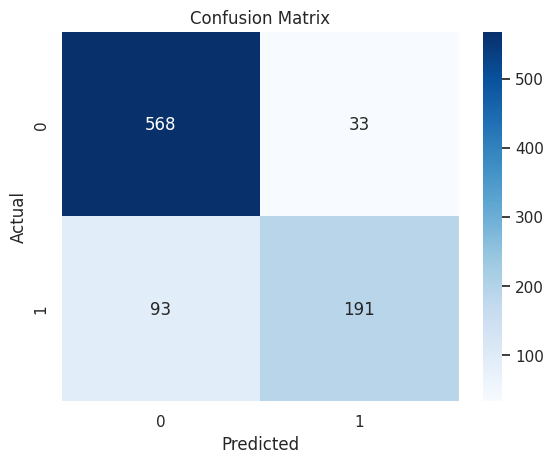

In [ ]:


# Pilih model terbaik (ganti sesuai kebutuhan)
y_pred = y_pred_rf
y_true = y_B_test

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

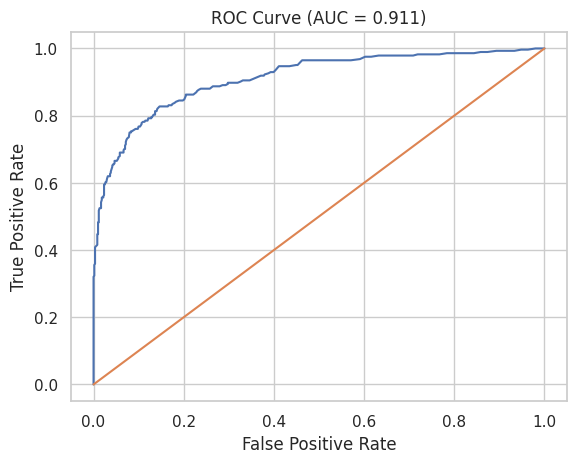

In [ ]:
y_proba = y_proba_rf

fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

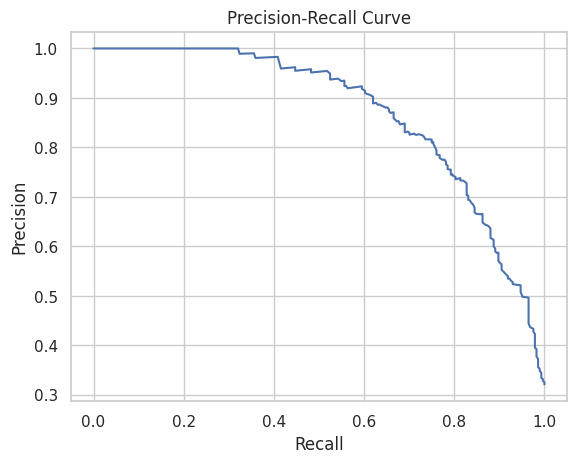

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### akses deployment 
https://lopingsuee-jaya-institut-dropout-analysis-xgf36hcgcjcmkerd9ody.streamlit.app/